# Simulazioni senza GWB (seed diversi)

Estratto da `Likelihood.ipynb`, celle 55–72 (copiate senza modifiche, output inclusi).

## Setup comune

Copia delle celle 0, 1, 3, 4, 6, 7, 9 di `Likelihood.ipynb`: import, caricamento della pulsar J1640+2224 (DR2low), modello, likelihood, prior, likelihood jittata.

In [40]:
import numpy as np
import os, glob, json
import pickle

import sys

# this is the path to the discovery folder
sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy
import jax.numpy as jnp

from scipy.stats import uniform
import re
from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
from scipy.stats import uniform
import jax

import time
import emcee

In [41]:
# path to the folder with the data
path = './dati/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
psr = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles][9] # we are only analysing pulsar #9

In [43]:
# data
model = [psr.residuals]
# timing model
model += [ds.makegp_timing(psr, svd=True)]
# white noise parameters
model += [ds.makenoise_measurement(psr, psr.noisedict, tnequad = True, ecorr=True)]
# red noise paramters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_red_components'], T=ds.getspan(psr), name='red_noise' ))
# DM variation parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_dm_components'], T=ds.getspan(psr), name='dm_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 2.0, tndm = False)))
# scattering noise parameters
model.append(ds.makegp_fourier(psr, ds.powerlaw, psr.noisedict[psr.name + '_chrom_components'], T=ds.getspan(psr), name='sv_gp', fourierbasis=ds.make_dmfourierbasis(alpha = 4.0, tndm = False)))

In [44]:
logL = ds.PulsarLikelihood(model).logL

In [46]:
# annoying function needed because the function logL want a dictionary as input, but our sampler wants a likelihood with an array as input
# so we have to switch from one to another :(
def params_dict_from_array(x):
    # ensure x is a plain numpy array before slicing
    x = np.asarray(x)
    return dict(zip(logL.params, x))

In [86]:
##### Cell for the prior distributions ###################################################################################

# dictionary with minimum and maximum value of the prior distribution
my_priordict = {}
my_priordict["(.*_)?sv_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?sv_gp_alpha.*"] = [0, 10]
my_priordict["(.*_)?sv_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_log10_A.*"] = [-10, 1]
my_priordict["(.*_)?sw_gamma.*"] = [-5, 6]
my_priordict["(.*_)?dm_gp_gamma.*"] = [0, 7]
my_priordict["(.*_)?dm_gp_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?red_noise_gamma.*"] = [0, 7]
my_priordict["(.*_)?red_noise_log10_A.*"] = [-20, -11]
my_priordict["(.*_)?sw_n_earth.*"] = [0, 30]


def build_priors(param_names, priordict):
    """
    Build a {param_name: scipy dist} dict with uniform prior distributions in the range
    """
    priors = {}
    unmatched = []
    for name in param_names:
        matched = False
        for pattern, (lo, hi) in priordict.items():
            if re.fullmatch(pattern, name):
                priors[name] = uniform(loc=lo, scale=hi - lo) ## this is where the uniform distribution is defined
                matched = True
                break
        if not matched:
            unmatched.append(name)

    if unmatched:
        print(f"Warning: no prior found for {len(unmatched)} parameters, "
              f"falling back to standard normal:\n  {unmatched}")
    return priors

priors = build_priors(logL.params, my_priordict)
priors

def log_prior(x):
    """Compute log prior"""
    params = params_dict_from_array(x)
    
    logp = 0.0
    for name, value in params.items():
        if name in priors:
            logp += priors[name].logpdf(value)
        else:
            # Default: standard normal prior
            if isinstance(value, np.ndarray):
                logp += -0.5 * np.sum(value**2)
            else:
                logp += -0.5 * value**2
    
    return logp

def prior_draw():
    """Draw from prior and return as flat array"""
    x = []
    for name in logL.params:
        x.append(priors[name].rvs())
    return np.array(x)

x0 = prior_draw()
x0

array([  1.41657955, -15.20565157,   3.04626604, -12.5891013 ,
         5.8842367 , -19.77807228])

In [49]:
@jax.jit # compile the likelihood in jax to make it faster
def _jit_logL(params_array):
    params = dict(zip(logL.params, params_array))
    return logL(params)

_jit_logL(x0)

def log_likelihood(x): 
    """
    Likelihood function that is given to the samples, it uses the jitted (=faster) version of the likelihood
    """
    x = np.asarray(x, dtype=np.float64)
    result = _jit_logL(jnp.array(x))
    return float(np.array(result))  # always a plain Python float

## Catene da altre analisi

Necessarie per i confronti incrociati di questo notebook. Copia delle celle 13 di `Likelihood.ipynb`: le catene vengono lette da disco (nessun sampling).

In [58]:
# read the output chain that has shape (n_samples, n_parameters)
chain = np.loadtxt('./test/chain_1.txt')[:, :-4]
chain = chain[len(chain) // 4:] # remove first 25% from the chain
chain.shape

(75001, 6)

## Analisi (celle 55–72 dell'originale)

In [10]:
# carica la pulsar simulata (residui sintetici generati dal codice Simulations)
sim_psr = ds.pulsar.Pulsar.read_feather('sim_data_noise/J1640+2224')

print('nome     :', sim_psr.name)
print('N_TOA    :', len(sim_psr.toas))
print('shape M  :', sim_psr.Mmat.shape)

nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


In [11]:
# stesso modello dell'analisi reale, ma sui dati simulati
model_sim = [sim_psr.residuals]
model_sim += [ds.makegp_timing(sim_psr, svd=True)]
model_sim += [ds.makenoise_measurement(sim_psr, sim_psr.noisedict, tnequad=True, ecorr=True)]
model_sim.append(ds.makegp_fourier(sim_psr, ds.powerlaw, sim_psr.noisedict[sim_psr.name + '_red_components'],
                                   T=ds.getspan(sim_psr), name='red_noise'))
model_sim.append(ds.makegp_fourier(sim_psr, ds.powerlaw, sim_psr.noisedict[sim_psr.name + '_dm_components'],
                                   T=ds.getspan(sim_psr), name='dm_gp',
                                   fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim.append(ds.makegp_fourier(sim_psr, ds.powerlaw, sim_psr.noisedict[sim_psr.name + '_chrom_components'],
                                   T=ds.getspan(sim_psr), name='sv_gp',
                                   fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))

logL_sim = ds.PulsarLikelihood(model_sim).logL
logL_sim.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [19]:
def params_dict_from_array_sim(x):
    x = np.asarray(x)
    return dict(zip(logL_sim.params, x))

# riusa lo stesso my_priordict e build_priors gia definiti nel notebook
priors_sim = build_priors(logL_sim.params, my_priordict)

def log_prior_sim(x):
    params = params_dict_from_array_sim(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim:
            logp += priors_sim[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim():
    return np.array([priors_sim[name].rvs() for name in logL_sim.params])

@jax.jit
def _jit_logL_sim(params_array):
    return logL_sim(dict(zip(logL_sim.params, params_array)))

def log_likelihood_sim(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim(jnp.array(x))))

x0_sim = prior_draw_sim()
print('logL iniziale =', log_likelihood_sim(x0_sim))

logL iniziale = 68166.2221878466


In [20]:
sampler_sim = ptmcmc(
    ndim=len(logL_sim.params),
    logl=log_likelihood_sim,
    logp=log_prior_sim,
    cov=np.eye(len(logL_sim.params)) * 0.001,
    outDir='./test_sim/',
    resume=True
)

In [97]:
print("Starting sampling (dati simulati)...")
sampler_sim.sample(x0_sim, Niter=1000000, thin=10)

Starting sampling (dati simulati)...
Resuming run from chain file ./test_sim//chain_1.txt
Resuming with 100001 samples from file representing 1000001 original samples
Adding DE jump with weight 20

Run Complete


In [85]:
chain_sim = np.loadtxt('./test_sim/chain_1.txt')[:, :-4]
chain_sim = chain_sim[len(chain_sim)//4:]
print('shape chain_sim:', chain_sim.shape)

shape chain_sim: (75001, 6)


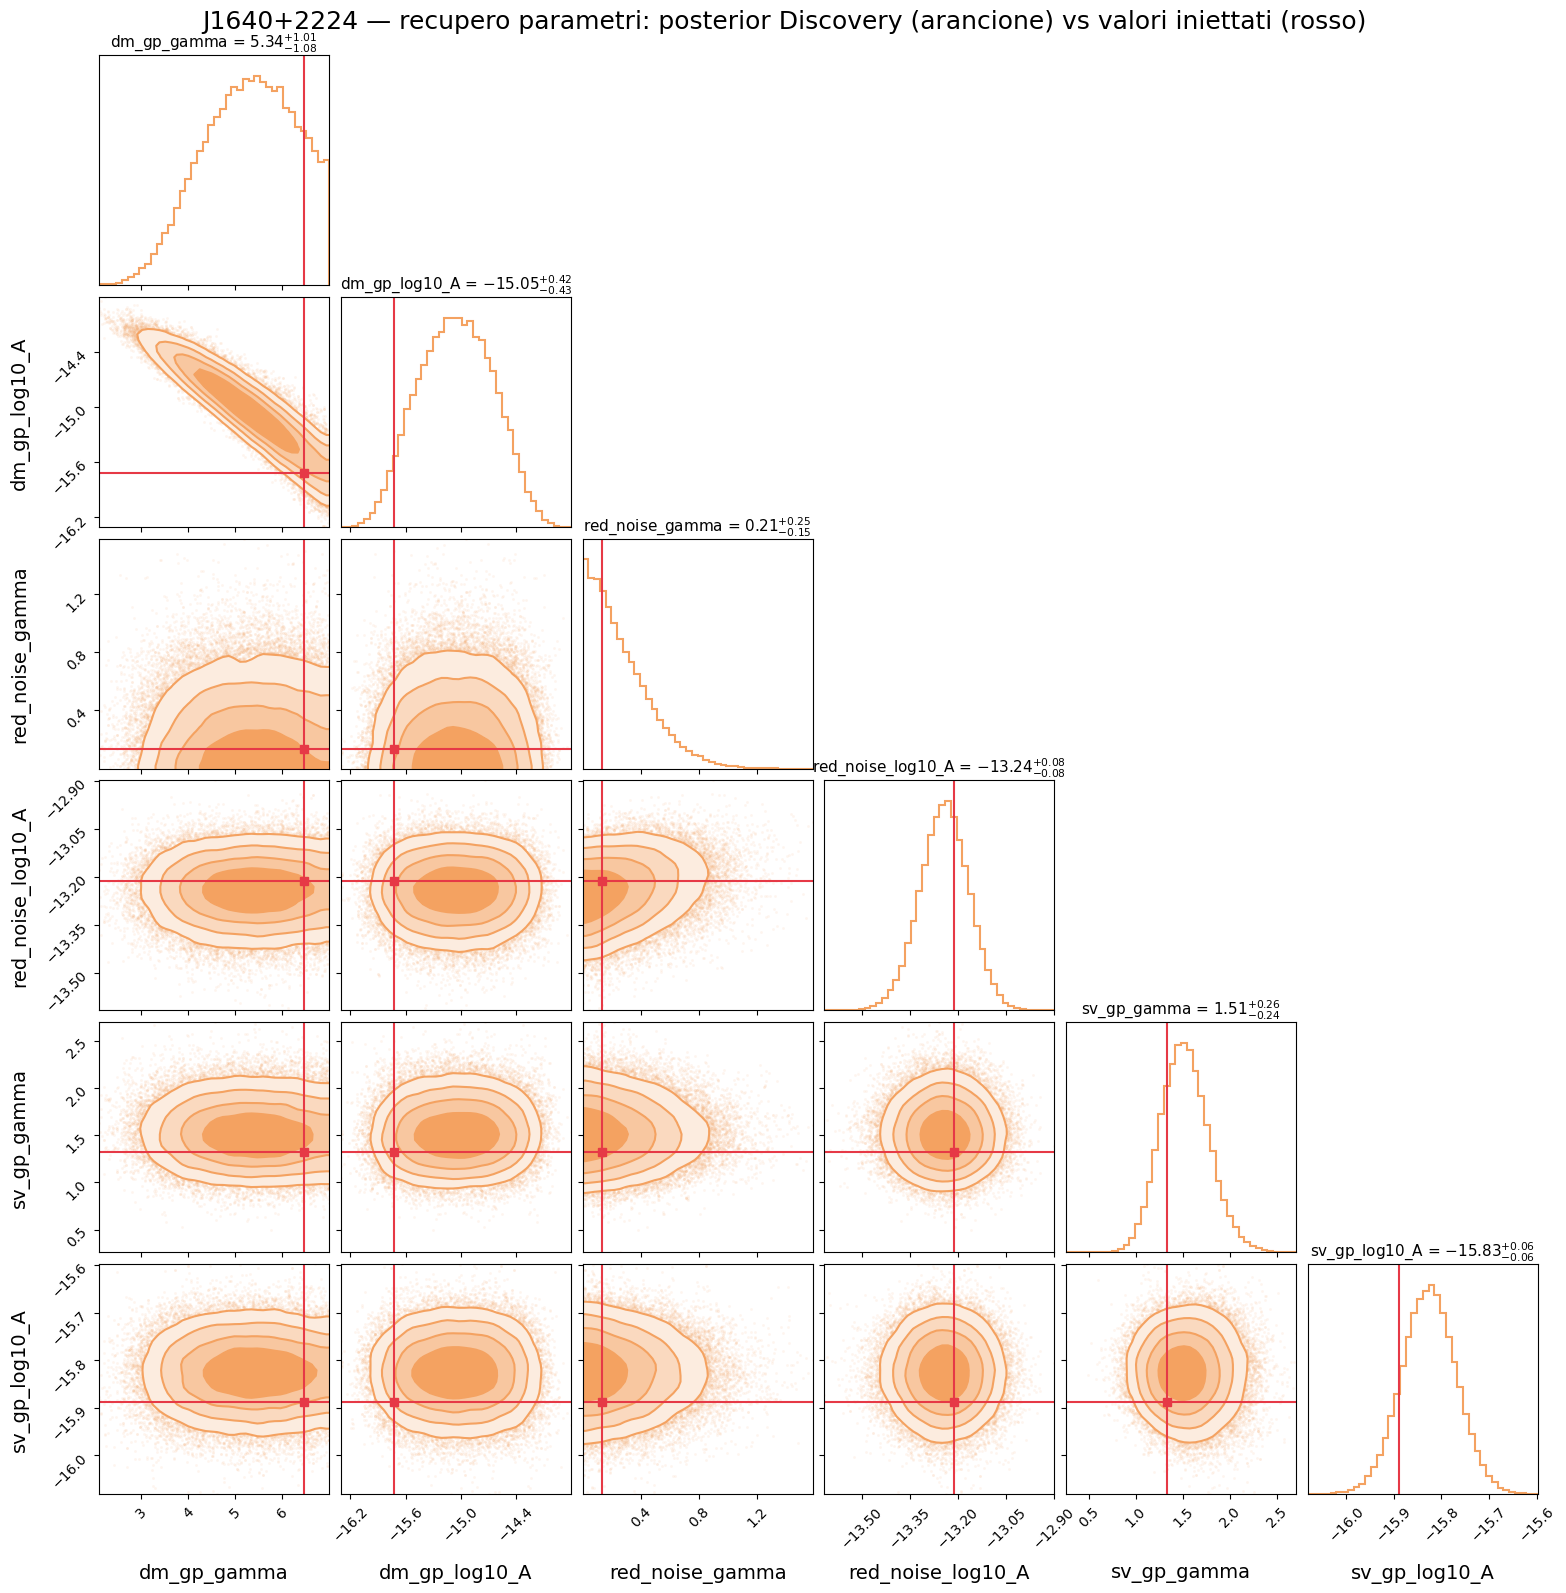

In [125]:
import corner

truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL_sim.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim.params]

fig = corner.corner(
    chain_sim[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#E63946',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#F4A261',
    hist_kwargs={'color': '#F4A261', 'linewidth': 1.5, 'density': True},
    plot_datapoints=True,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    smooth1d=None,
    bins=40,
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — recupero parametri: posterior Discovery (arancione) vs valori iniettati (rosso)',
             fontsize=18, y=1.00)
fig.savefig('corner_recovery_sim.png', dpi=150, bbox_inches='tight')

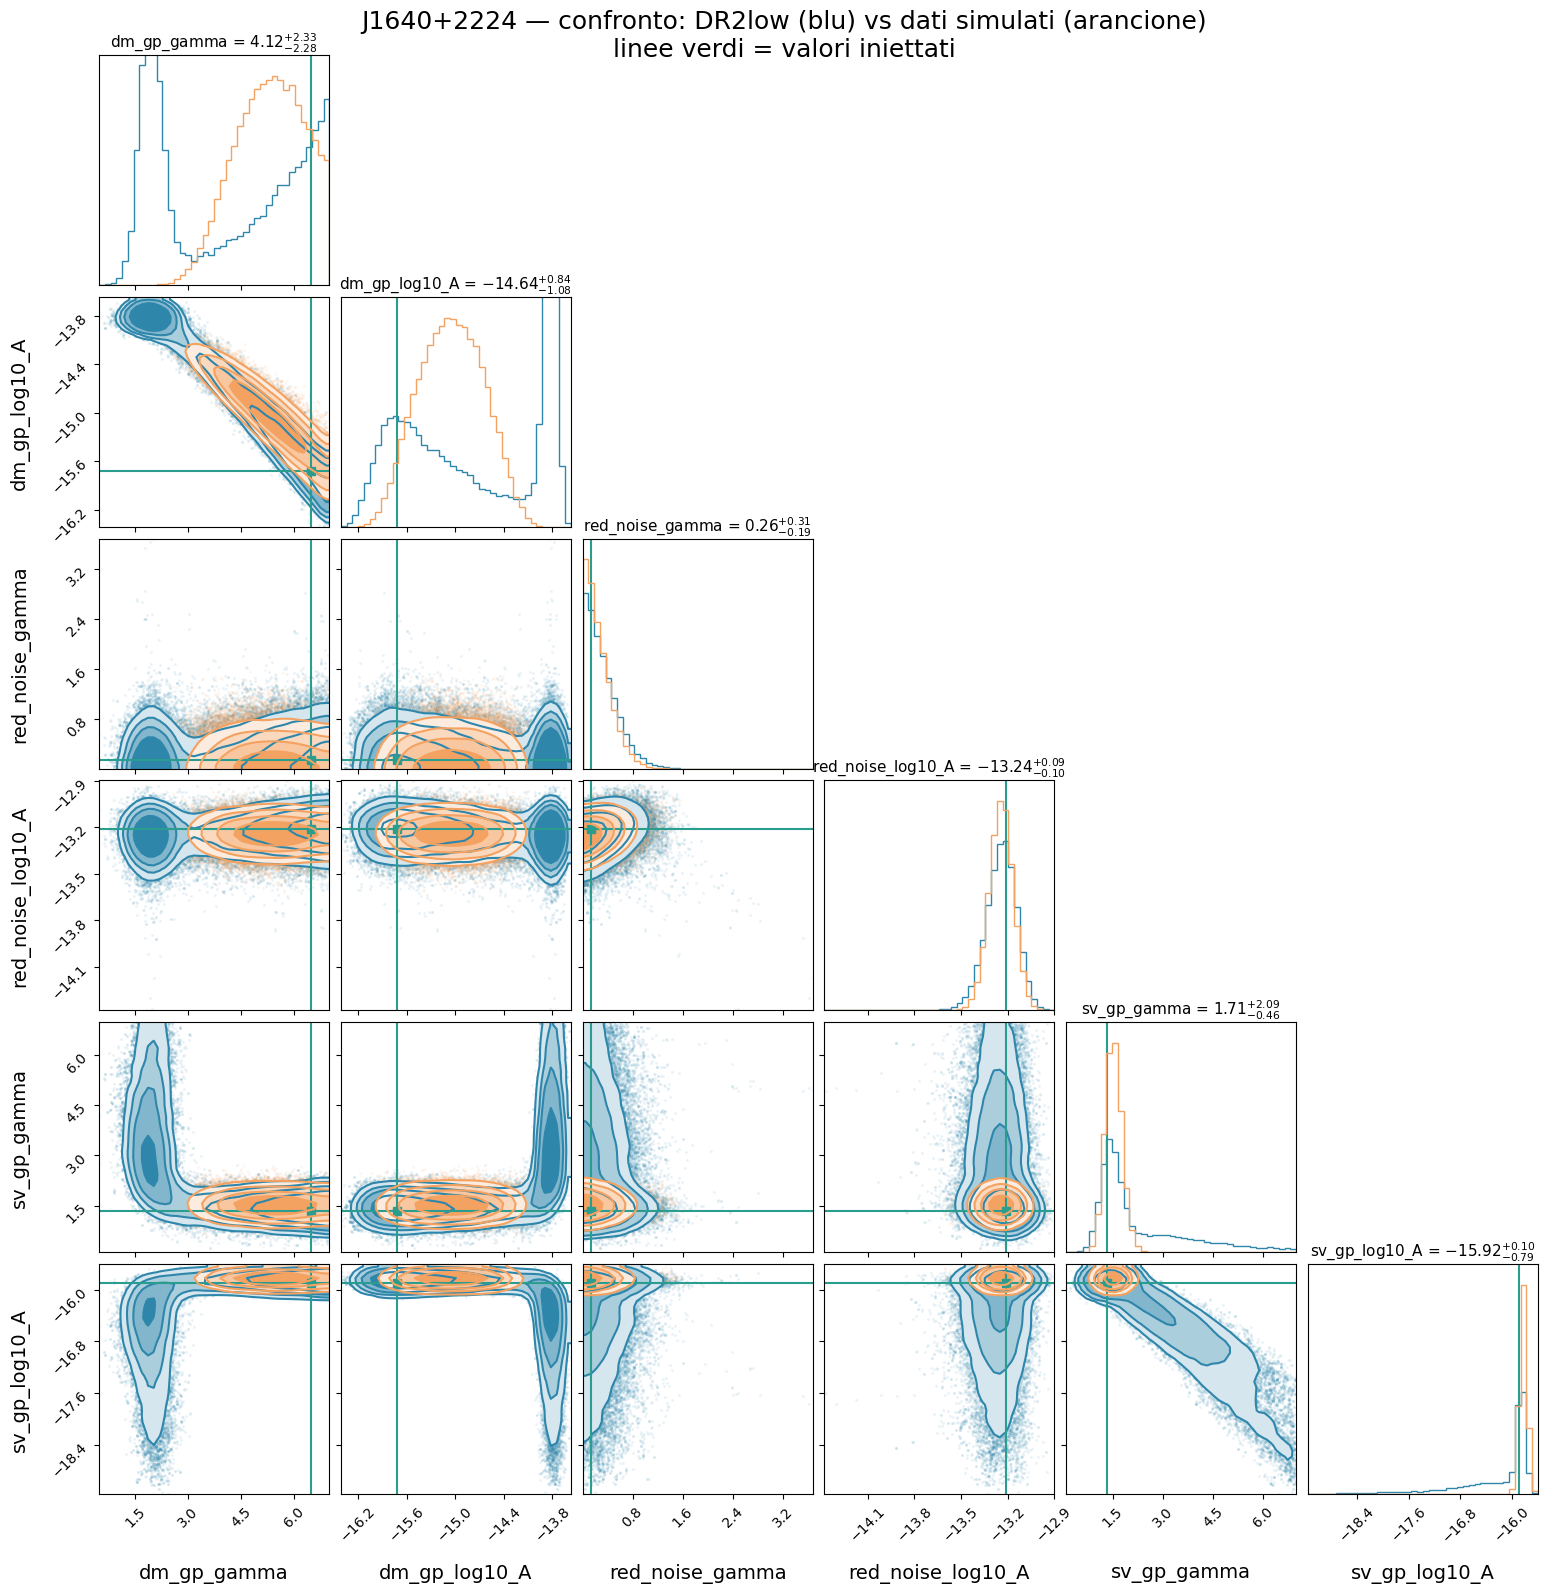

In [122]:
import corner
import numpy as np

clean_labels = [name.replace('J1640+2224_', '') for name in logL.params]

# valori veri iniettati, nell'ordine dei parametri
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}
truth_values = [truths_dict[p] for p in logL.params]

# range comune che contiene entrambe le catene (per una sovrapposizione equa)
both = np.vstack([chain[:], chain_sim[:]])
common_range = [(both[:, i].min(), both[:, i].max()) for i in range(both.shape[1])]

# Dati REALI in blu
fig = corner.corner(
    chain[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#2A9D8F',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#2E86AB',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    hist_kwargs={"density": True}
)

# Dati SIMULATI in rosso, sovrapposti
corner.corner(
    chain_sim[:],
    labels=clean_labels,
    show_titles=False,
    color='#F4A261',
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0, smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
    hist_kwargs={"density": True}
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto: DR2low (blu) vs dati simulati (arancione)\nlinee verdi = valori iniettati',
             fontsize=18, y=1.00)
fig.savefig('corner_reali_vs_simulati.png', dpi=150, bbox_inches='tight')

In [21]:
sim2_psr = ds.pulsar.Pulsar.read_feather('sim_data_noise2/J1640+2224') # seed = 17 
print('nome     :', sim2_psr.name)
print('N_TOA    :', len(sim2_psr.toas))
print('shape M  :', sim2_psr.Mmat.shape)

nome     : J1640+2224
N_TOA    : 6777
shape M  : (6777, 39)


In [22]:
model_sim2 = [sim2_psr.residuals]
model_sim2 += [ds.makegp_timing(sim2_psr, svd=True)]
model_sim2 += [ds.makenoise_measurement(sim2_psr, sim2_psr.noisedict, tnequad=True, ecorr=True)]
model_sim2.append(ds.makegp_fourier(sim2_psr, ds.powerlaw, sim2_psr.noisedict[sim2_psr.name + '_red_components'],
                                    T=ds.getspan(sim2_psr), name='red_noise'))
model_sim2.append(ds.makegp_fourier(sim2_psr, ds.powerlaw, sim2_psr.noisedict[sim2_psr.name + '_dm_components'],
                                    T=ds.getspan(sim2_psr), name='dm_gp',
                                    fourierbasis=ds.make_dmfourierbasis(alpha=2.0, tndm=False)))
model_sim2.append(ds.makegp_fourier(sim2_psr, ds.powerlaw, sim2_psr.noisedict[sim2_psr.name + '_chrom_components'],
                                    T=ds.getspan(sim2_psr), name='sv_gp',
                                    fourierbasis=ds.make_dmfourierbasis(alpha=4.0, tndm=False)))

logL_sim2 = ds.PulsarLikelihood(model_sim2).logL
logL_sim2.params

['J1640+2224_dm_gp_gamma',
 'J1640+2224_dm_gp_log10_A',
 'J1640+2224_red_noise_gamma',
 'J1640+2224_red_noise_log10_A',
 'J1640+2224_sv_gp_gamma',
 'J1640+2224_sv_gp_log10_A']

In [23]:
def params_dict_from_array_sim2(x):
    x = np.asarray(x)
    return dict(zip(logL_sim2.params, x))

priors_sim2 = build_priors(logL_sim2.params, my_priordict)

def log_prior_sim2(x):
    params = params_dict_from_array_sim2(x)
    logp = 0.0
    for name, value in params.items():
        if name in priors_sim2:
            logp += priors_sim2[name].logpdf(value)
        else:
            logp += -0.5 * np.sum(np.asarray(value)**2)
    return logp

def prior_draw_sim2():
    return np.array([priors_sim2[name].rvs() for name in logL_sim2.params])

x0_sim2 = prior_draw_sim2()

In [24]:
@jax.jit
def _jit_logL_sim2(params_array):
    return logL_sim2(dict(zip(logL_sim2.params, params_array)))

def log_likelihood_sim2(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.array(_jit_logL_sim2(jnp.array(x))))

print('logL iniziale =', log_likelihood_sim2(x0_sim2))

logL iniziale = 67949.53347287004


In [25]:
sampler_sim2 = ptmcmc(
    ndim=len(logL_sim2.params),
    logl=log_likelihood_sim2,
    logp=log_prior_sim2,
    cov=np.eye(len(logL_sim2.params)) * 0.001,
    outDir='./test_sim2/',
    resume=True
)

In [26]:
print("Starting sampling (dati simulati, seed 42)...")
sampler_sim2.sample(x0_sim2, Niter=1000000, thin=10)

Starting sampling (dati simulati, seed 42)...
Finished 1.00 percent (1.00 percent of new work) in 13.370369 s Acceptance rate = 0.2734Adding DE jump with weight 20
Finished 100.00 percent (100.00 percent of new work) in 2388.810439 s Acceptance rate = 0.388759
Run Complete


In [8]:
chain_sim2 = np.loadtxt('./test_sim2/chain_1.txt')[:, :-4]
chain_sim2 = chain_sim2[len(chain_sim2)//4:]
chain_sim2.shape   # atteso (~75000, 6)

(75001, 6)

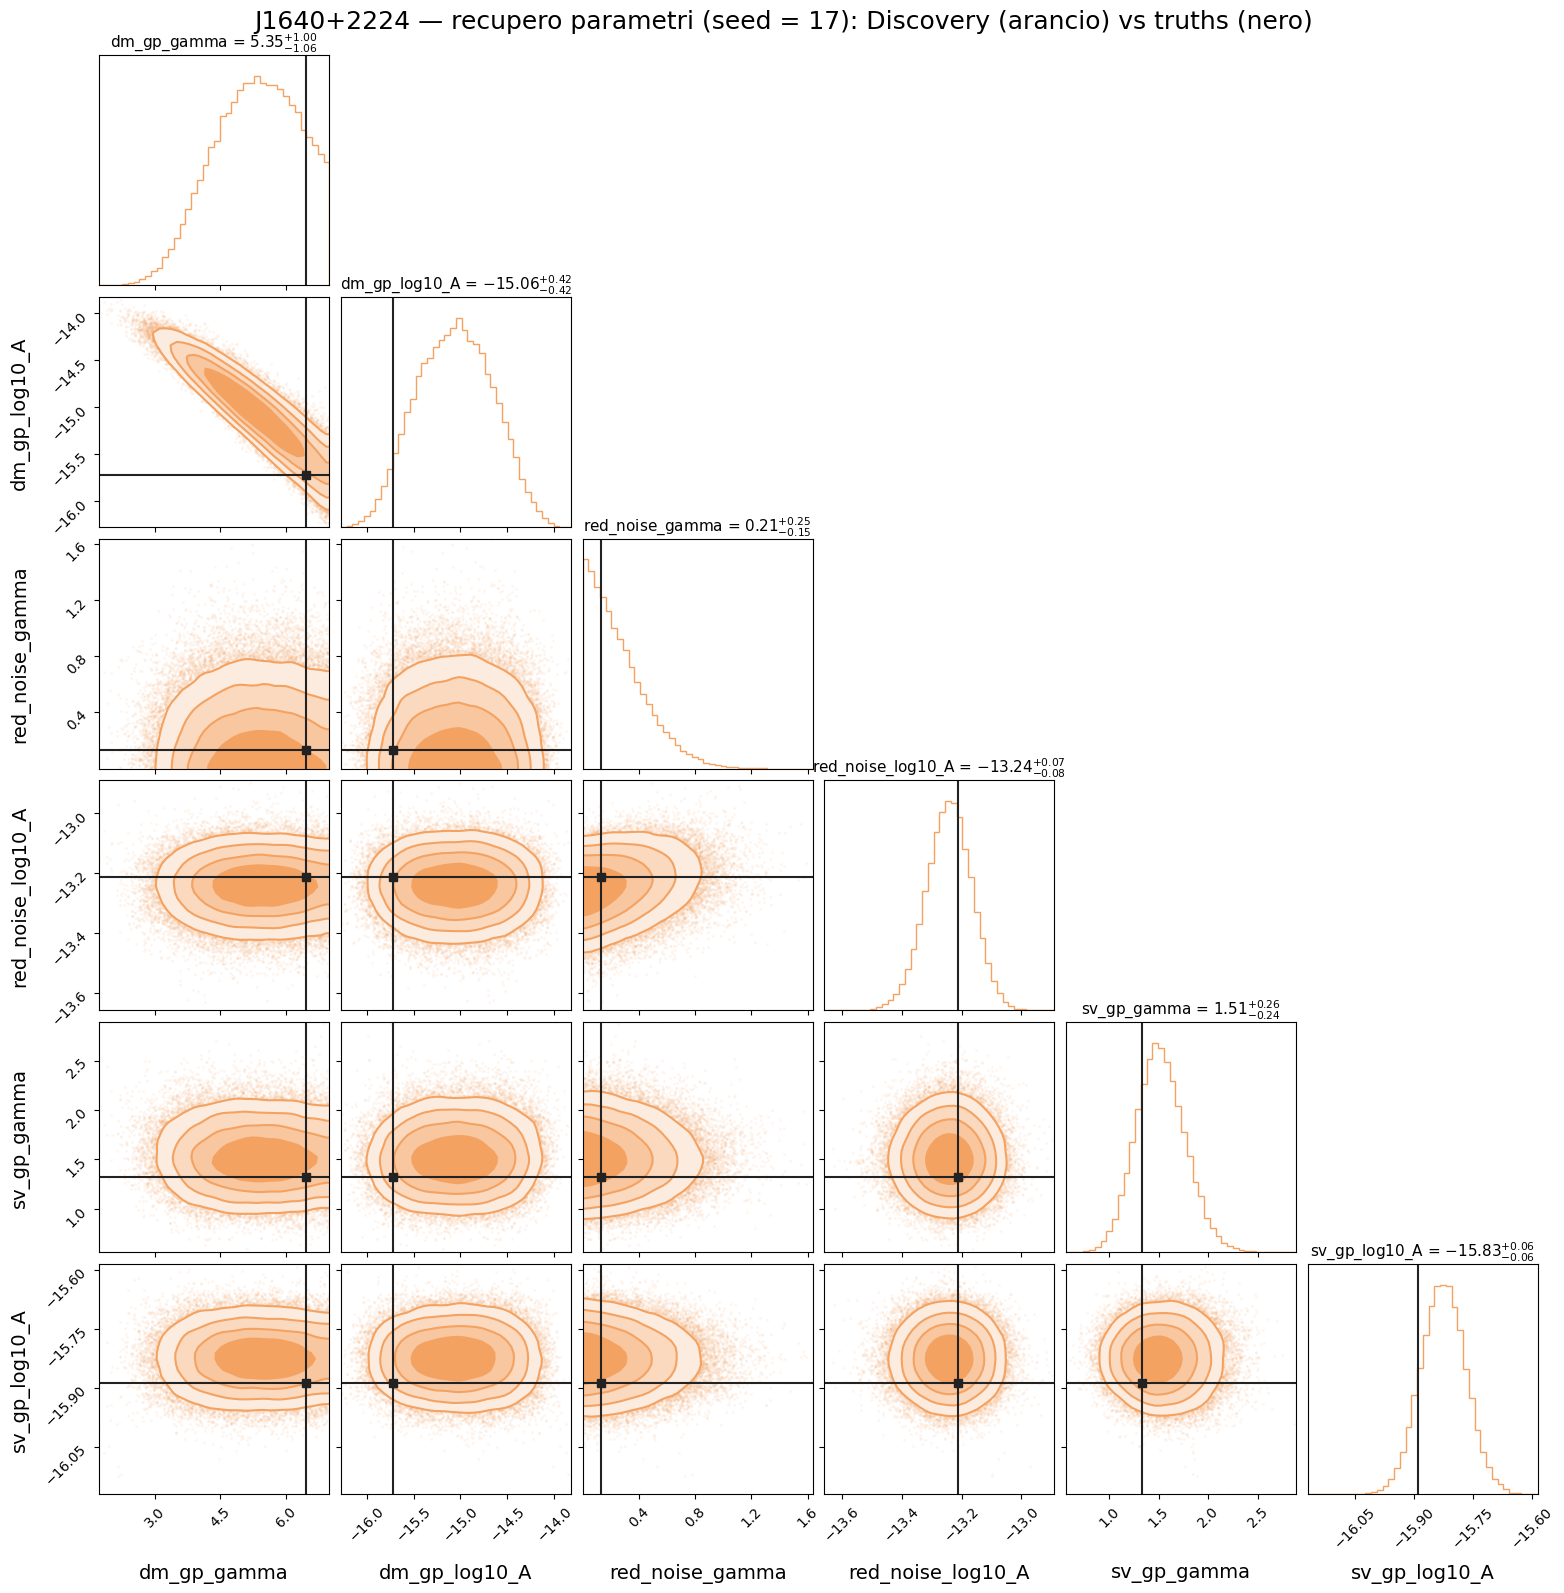

In [128]:
import corner

# valori veri iniettati (stessi per tutti i campioni simulati: cambia solo il seed)
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}

truth_values = [truths_dict[p] for p in logL_sim2.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim2.params]

fig = corner.corner(
    chain_sim2[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#F4A261',
    hist_kwargs={'density': True},
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    bins=40,
)
fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — recupero parametri (seed = 17): Discovery (arancio) vs truths (nero)',
             fontsize=18, y=1.00)
fig.savefig('corner_recovery_sim2.png', dpi=150, bbox_inches='tight')

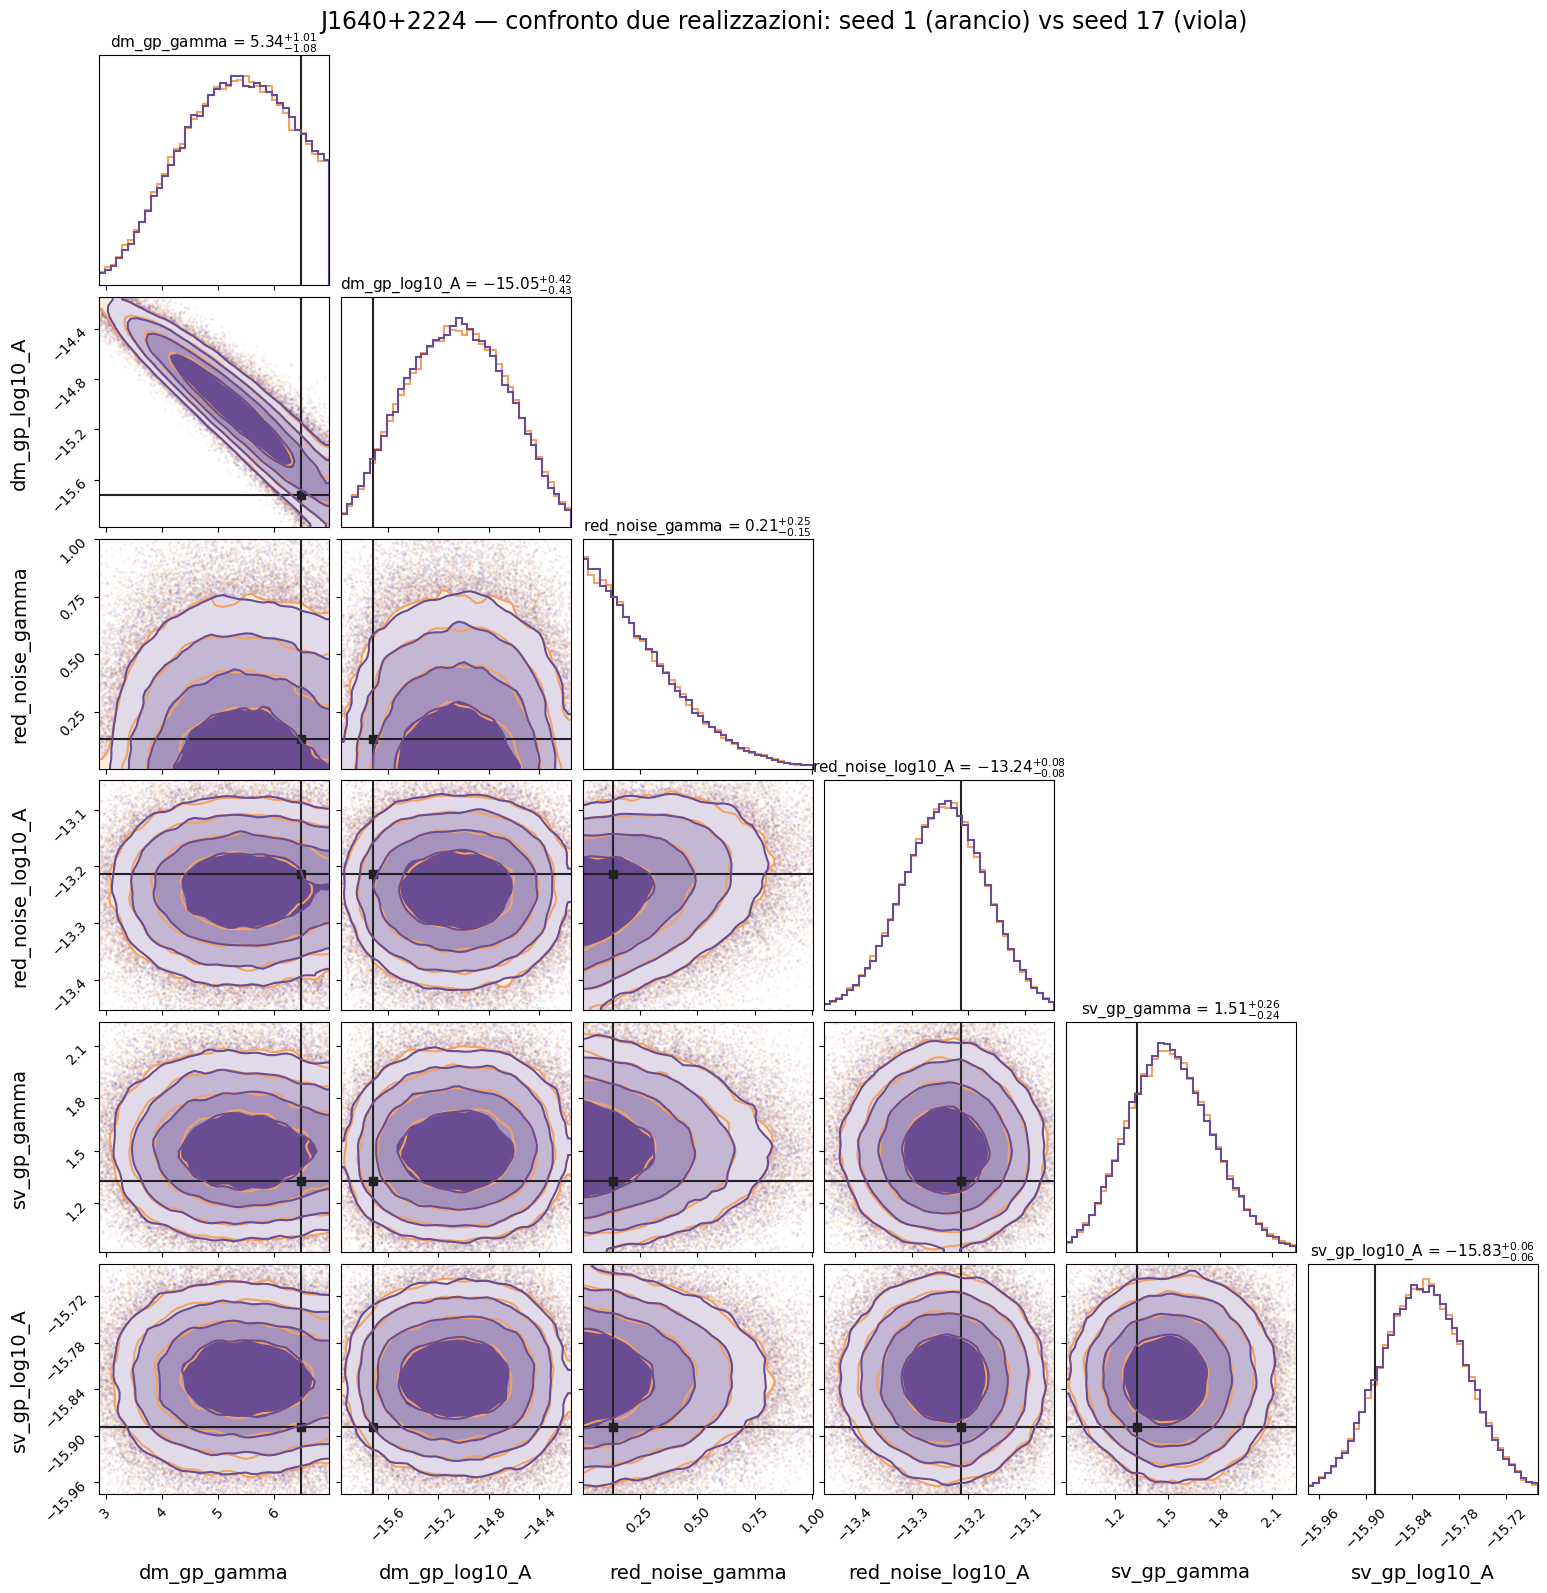

In [135]:
import corner
import numpy as np

# valori veri iniettati (stessi per entrambe le realizzazioni: cambia solo il seed)
truths_dict = {
    'J1640+2224_dm_gp_gamma': 6.471070651479037,
    'J1640+2224_dm_gp_log10_A': -15.7227863246785,
    'J1640+2224_red_noise_gamma': 0.13235259553929019,
    'J1640+2224_red_noise_log10_A': -13.212902548624186,
    'J1640+2224_sv_gp_gamma': 1.3259815720503758,
    'J1640+2224_sv_gp_log10_A': -15.888300265911965,
}

# range comune coi quantili
both = np.vstack([chain_sim[:], chain_sim2[:]])
common_range = [(np.percentile(both[:, i], 0.5), np.percentile(both[:, i], 99.5))
                for i in range(both.shape[1])]

truth_values = [truths_dict[p] for p in logL_sim2.params]
clean_labels = [name.replace('J1640+2224_', '') for name in logL_sim2.params]

# sim originale (seed 1) in arancio
fig = corner.corner(
    chain_sim[:],
    labels=clean_labels,
    truths=truth_values,
    truth_color='#222222',
    show_titles=True,
    title_fmt='.2f',
    label_kwargs={'fontsize': 14},
    title_kwargs={'fontsize': 11},
    color='#F4A261',
    hist_kwargs={'color': '#F4A261', 'linewidth': 1.5, 'density': True},
    plot_datapoints=True,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    smooth1d=None,
    bins=40,
    range=common_range,
)

# sim nuovo (seed 17) in viola
corner.corner(
    chain_sim2[:],
    labels=clean_labels,
    show_titles=False,
    color='#6A4C93',
    hist_kwargs={'color': '#6A4C93', 'linewidth': 1.5, 'density': True},
    plot_datapoints=True,
    plot_density=True,
    plot_contours=True,
    fill_contours=True,
    levels=(0.39, 0.68, 0.86, 0.95),
    smooth=1.0,
    smooth1d=None,
    bins=40,
    range=common_range,
    fig=fig,
)

fig.set_size_inches(16, 16)
fig.suptitle('J1640+2224 — confronto due realizzazioni: seed 1 (arancio) vs seed 17 (viola)',
             fontsize=17, y=1.00)
fig.savefig('corner_sim_seed17_vs_seed1.png', dpi=150, bbox_inches='tight')